In [2]:
import pandas as pd

In [34]:
paths = ({
    'invoice_level_table': '../data/D3_invoice-level table.csv',
    'time_series_graph': '../outputs/D5_time_series_graph.png'
})

In [4]:
df = pd.read_csv(paths['invoice_level_table'])
df['invoice_first_date'] = pd.to_datetime(df['invoice_first_date'])
df.head()

,InvoiceNo,invoice_first_date,customer_id,country,invoice_revenue,n_lines
0,536365,2010-12-01 08:26:00,17850.0,United Kingdom,139.12,7
1,536366,2010-12-01 08:28:00,17850.0,United Kingdom,22.20,2
2,536367,2010-12-01 08:34:00,13047.0,United Kingdom,278.73,12
3,536368,2010-12-01 08:34:00,13047.0,United Kingdom,70.05,4
4,536369,2010-12-01 08:35:00,13047.0,United Kingdom,17.85,1


#### 1. periodic sum using `.resample` (D/W/ME)

In [20]:
series_day = df.resample('D', on='invoice_first_date')['invoice_revenue'].sum()
series_week = df.resample('W', on='invoice_first_date')['invoice_revenue'].sum()
series_month = df.resample('ME', on='invoice_first_date')['invoice_revenue'].sum()
series_month

invoice_first_date
2010-12-31     572713.890
2011-01-31     569445.040
2011-02-28     447137.350
2011-03-31     595500.760
2011-04-30     469200.361
2011-05-31     678594.560
2011-06-30     661213.690
2011-07-31     600091.011
2011-08-31     645343.900
2011-09-30     952838.382
2011-10-31    1039318.790
2011-11-30    1161817.380
2011-12-31     518192.790
Freq: ME, Name: invoice_revenue, dtype: float64

#### 2. monthly MoM growth using `pct_change`

Month-over-Month (MoM) growth measures the percentage change in a business metric (like revenue or users) compared to the previous month.

In [7]:
series_month.pct_change(periods=1)

invoice_first_date
2010-12-31         NaN
2011-01-31   -0.005708
2011-02-28   -0.214784
2011-03-31    0.331807
2011-04-30   -0.212091
2011-05-31    0.446279
2011-06-30   -0.025613
2011-07-31   -0.092440
2011-08-31    0.075410
2011-09-30    0.476482
2011-10-31    0.090761
2011-11-30    0.117864
2011-12-31   -0.553981
Freq: ME, Name: invoice_revenue, dtype: float64

#### 3. rolling window mean using `.rolling` (mean/std)

In [41]:
# prep time series data with sorting
df_day = pd.DataFrame({
    'date': series_day.index,
    'revenue': series_day.values
})

# prep time series data with sorting
df_day.sort_values('date', inplace=True)

# 7 day rolling average
df_day['mean_7'] = df_day['revenue'].rolling(window=7).mean()

# 7 day rolling std
df_day['std_7'] = df_day['revenue'].rolling(window=7).std()

#### 4. find spike day: `daily > mean_7 + 2* std_7`

In [42]:
spike_day = df_day['revenue'] > df_day['mean_7'] + 2 * df_day['std_7']
df_day = df_day.assign(spike=spike_day)
df_day

,date,revenue,mean_7,std_7,spike
0,2010-12-01,46376.49,NaN,NaN,False
1,2010-12-02,47316.53,NaN,NaN,False
2,2010-12-03,23921.71,NaN,NaN,False
3,2010-12-04,0.00,NaN,NaN,False
4,2010-12-05,31771.60,NaN,NaN,False
...,...,...,...,...,...
369,2011-12-05,58202.21,36879.822857,19881.302258,False
370,2011-12-06,46144.04,36493.017143,19634.366563,False
371,2011-12-07,69354.21,40474.871429,23298.925890,False
372,2011-12-08,50519.41,41329.931429,23580.847115,False


In [45]:
# spike day count
df_day[df_day['spike']==True]

,date,revenue,mean_7,std_7,spike
34,2011-01-04,12125.46,1732.208571,4582.993099,True
35,2011-01-05,28803.63,5847.012857,11085.748854,True
48,2011-01-18,87589.11,26183.684286,29686.925577,True
373,2011-12-09,184349.28,61277.872857,59152.317195,True


#### 5. visualization

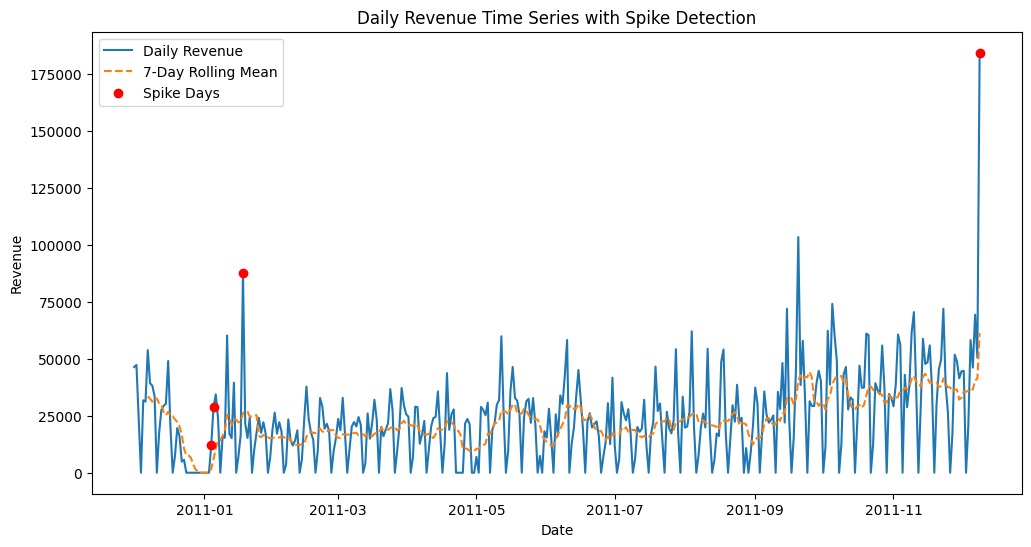

In [44]:
import matplotlib.pyplot as plt

# Plot the time series
plt.figure(figsize=(12, 6))
plt.plot(df_day['date'], df_day['revenue'], label='Daily Revenue')
plt.plot(df_day['date'], df_day['mean_7'], label='7-Day Rolling Mean', linestyle='--')

# Highlight spike days
spike_dates = df_day[df_day['spike']]['date']
spike_revenues = df_day[df_day['spike']]['revenue']
plt.scatter(spike_dates, spike_revenues, color='red', label='Spike Days', zorder=5)

plt.xlabel('Date')
plt.ylabel('Revenue')
plt.title('Daily Revenue Time Series with Spike Detection')
plt.legend()
plt.savefig(paths['time_series_graph'], dpi=300, bbox_inches='tight')
plt.show()